In [1]:
import sys
sys.path.append("C:/Users/rozhkova_as/Desktop/Rozhkova/Projects/DL/VAE_Python")  # путь к VAE.py

import torch.optim as optim
from VAE import VAE, KLDLoss, VAEConfig
from StepByStep import VAEStepByStep
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from tensorboard.backend.event_processing import event_accumulator
import os
import re
from PIL import Image
import io
from IPython.display import HTML

<h1>Обучение модели<h1>

In [3]:
for latent_dim in [16, 32, 64, 128, 256, 512]:

    config = VAEConfig(latent_dim = latent_dim)
    model = VAE(config)
    loss_fn = KLDLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    sbs = VAEStepByStep(model, loss_fn=loss_fn, optimizer=optimizer)
    print(sbs.device)
    train_data_folder = 'C:\\Users\\rozhkova_as\\Desktop\\Rozhkova\\Projects\\DL\\data\\mvtec_anomaly_detection\\screw\\train'
    test_data_folder = 'C:\\Users\\rozhkova_as\\Desktop\\Rozhkova\\Projects\\DL\\data\\mvtec_anomaly_detection\\screw\\test'
    sbs.prepare_data(train_data_folder, test_data_folder, batch_size=32)
    sbs.set_tensorboard(f"{latent_dim}", folder = 'runs\\Latent Dim')

    num_epochs = 80
    train_losses=sbs.train(n_epochs=num_epochs)

cuda
Epoch: 1 | Loss: 49506.3820 | Reconstruction Loss: 49045.7223 | KL Divergence: 460.66015196
Epoch: 2 | Loss: 31696.0131 | Reconstruction Loss: 29807.9711 | KL Divergence: 1888.04219971
Epoch: 3 | Loss: 17854.5503 | Reconstruction Loss: 17293.1936 | KL Divergence: 561.35693665
Epoch: 4 | Loss: 11356.1756 | Reconstruction Loss: 11119.1147 | KL Divergence: 237.06075134
Epoch: 5 | Loss: 7391.7304 | Reconstruction Loss: 7109.0058 | KL Divergence: 282.72469940
Epoch: 6 | Loss: 5953.3788 | Reconstruction Loss: 5754.6346 | KL Divergence: 198.74418640
Epoch: 7 | Loss: 5270.1310 | Reconstruction Loss: 5096.3997 | KL Divergence: 173.73130798
Epoch: 8 | Loss: 4731.6114 | Reconstruction Loss: 4586.8167 | KL Divergence: 144.79469299
Epoch: 9 | Loss: 4164.7701 | Reconstruction Loss: 4026.0238 | KL Divergence: 138.74645386
Epoch: 10 | Loss: 3769.7568 | Reconstruction Loss: 3638.8820 | KL Divergence: 130.87480164
Epoch: 11 | Loss: 3634.3257 | Reconstruction Loss: 3513.0985 | KL Divergence: 121.227

<h1> Вывод результатов <h1>
<h2>Подготовка логов<h2>

In [2]:
log_dir = "runs\\Latent Dim"  # путь к логам
runs = os.listdir(log_dir)

def extract_dim(name):
    return int(re.search(r'^\d+', name).group())

runs_sorted = sorted(runs, key=extract_dim)

<h2>Total Loss<h2>

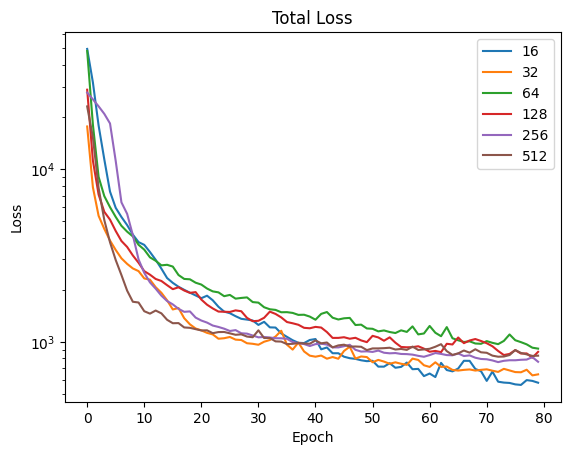

In [13]:
for run in runs_sorted:
    path = os.path.join(log_dir, run)
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()
    
    match = re.search(r'\d+', path)
    if match:
        label = int(match.group())

    if 'Loss/train' in ea.Tags()['scalars']:
        events = ea.Scalars("Loss/train")
        steps = [e.step for e in events]
        values = [e.value for e in events]

        plt.plot(steps, values, label = label)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Total Loss')
plt.show()

<h2>Reconstruction Loss<h2>

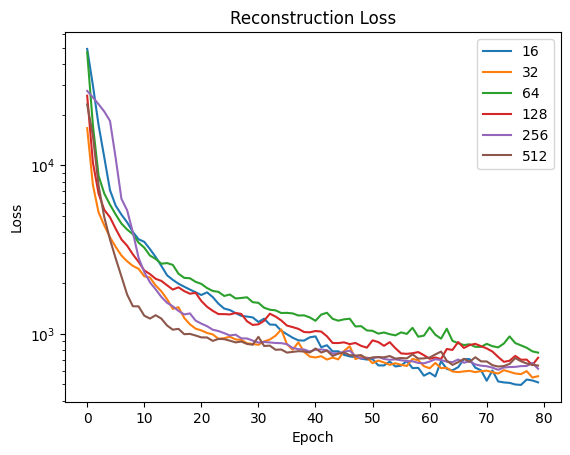

In [19]:
for run in runs_sorted:
    path = os.path.join(log_dir, run)
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    match = re.search(r'\d+', path)
    if match:
        label = int(match.group())

    if 'Reconstruction Loss/train' in ea.Tags()['scalars']:
        events = ea.Scalars("Reconstruction Loss/train")
        steps = [e.step for e in events]
        values = [e.value for e in events]

        plt.plot(steps, values, label = label)

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.show()

<h2>KL Loss<h2>

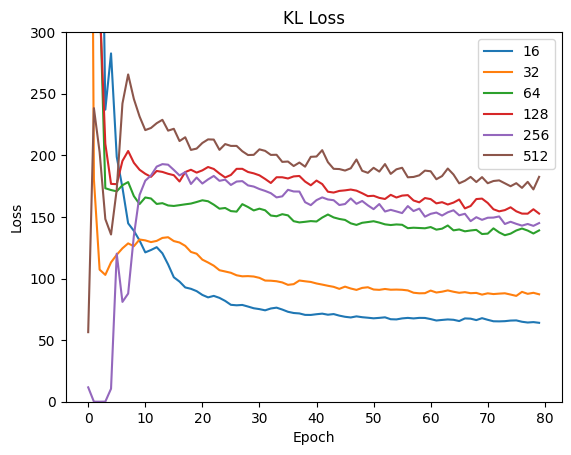

In [24]:
for run in runs_sorted:
    path = os.path.join(log_dir, run)
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    match = re.search(r'\d+', path)
    if match:
        label = int(match.group())

    if 'KL Divergence/train' in ea.Tags()['scalars']:
        events = ea.Scalars("KL Divergence/train")
        steps = [e.step for e in events]
        values = [e.value for e in events]

        plt.plot(steps, values, label = label)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 300)
plt.title('KL Loss')
plt.legend()
plt.show()

<h2>Отображение процесса обучения модели на изображениях<h2>

In [4]:
save_dir = "output/training"
os.makedirs(save_dir, exist_ok=True)

for run in runs_sorted:
    path = os.path.join(log_dir, run)

    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    match = re.search(r'\d+', path)
    if match:
        label = int(match.group())

    if 'Images/test_image' in ea.Tags()['images']:
        events = ea.Images("Images/test_image")
        
        fig, ax = plt.subplots()
        ax.axis('off')

        first_img = Image.open(io.BytesIO(events[0].encoded_image_string))
        im = ax.imshow(first_img)
        
        def update(i):
            img = Image.open(io.BytesIO(events[i].encoded_image_string))
            im.set_data(img)
            ax.set_title(f"{run} | step {events[i].step}")
            return [im]
        
        anim = animation.FuncAnimation(
            fig,
            update,
            frames=len(events),
            interval=300
        )
        
        anim.save(f"output\\training\\{label}.gif",writer='pillow',fps=3)
        plt.close()

        display(HTML(anim.to_jshtml()))
